## Import Library

In [ ]:
!pip install -U -q bitsandbytes transformers accelerate peft trl
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 134.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 630.8/630.8 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.3 MB/s eta 0:00:00


In [ ]:
from transformers import TrainingArguments, AutoModelForCausalLM, AutoTokenizer, pipeline
from transformers import AutoProcessor
from peft import LoraConfig, PeftModel, get_peft_model, TaskType
from datasets import load_dataset
import matplotlib.pyplot as plt
from trl import SFTTrainer
import torch


In [ ]:
# from transformers import AutoProcessor, AutoModelForImageTextToText

### Import Credentials and Message Prompt

In [ ]:
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
base_model = "Qwen/Qwen3.5-0.8B-Base"
fined_tuned_model = userdata.get('FINED_TUNED_MODEL_REPO_ID')

In [ ]:
messages = [
    {
        "role": "system",
        "content": "You are a senior legal and financial advisor specializing in: Federal Tax Law (IRC, Treasury Regulations, IRS guidance), SEC Regulations (Securities Act 1933",
    },
    {"role": "user", "content": "What consequence will I face when I didn't pay for taxes fo few years?"},
]

## Qwen3.5-0.8B-Base

In [ ]:
pipe = pipeline(
    "text-generation",
    model=base_model,
    dtype=torch.bfloat16,
    device_map="auto"
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

In [ ]:
prompt = pipe.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

outputs = pipe(
    prompt,
    max_new_tokens=400,
    do_sample=True,
    temperature=0.5
)

Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
# 4. Print the result
print(outputs[0]["generated_text"].split("</think>")[-1].strip())

As a senior legal and financial advisor, I understand your concern. The consequences of underpayment on taxes for several years are significant and can affect your financial situation in multiple ways. Here's a detailed breakdown:

## **Immediate Consequences**
- **IRS Notice of Underpayment**: You'll receive a formal notice from the IRS stating you owe money
- **Potential Additional Interest**: Interest may accrue on the unpaid balance
- **Potential Collection Actions**: The IRS may pursue collection actions, including:
  - Wage garnishment (up to 25% of your gross pay)
  - Bank account freezing
  - Credit card debt collection
  - Asset seizure (in some cases)

## **Long-Term Financial Impact**
- **Tax Liability**: You'll be responsible for the full amount you owe, which may be significant
- **Interest Costs**: Interest may compound over time, increasing your debt
- **Penalties**: The IRS may impose additional penalties for late payments
- **Interest Rates**: Higher interest rates cou

## Fine-tuned Qwen3.5-0.8B-Base (Adapter Tuning)

### Convert dataset to suitable for fine tuning

In [ ]:
us_finance_datasets = "Gregorgramtoshi/us-legal-finance-sft-v0.1"

In [ ]:
dataset = load_dataset(us_finance_datasets, split="train")
train_data = dataset.select_columns(['text'])
train_data[0]

README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/555k [00:00<?, ?B/s]

eval.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/125 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25 [00:01<?, ? examples/s]

{'text': '<|system|>\nYou are a senior legal and financial advisor specializing in:\n- US Corporate Finance (M&A, capital markets, debt/equity structuring)\n- Federal Tax Law (IRC, Treasury Regulations, IRS guidance)\n- SEC Regulations (Securities Act 1933, Exchange Act 1934, Regulation S-K/S-X, Rule 10b-5)\n- AML/KYC Compliance (Bank Secrecy Act, FinCEN rules, FATF standards, USA PATRIOT Act)\n<|user|>\nWhen an issuer utilizing an effective Form S-3 shelf registration statement intends to conduct an At-the-Market (ATM) offering through a designated sales agent, how must the issuer navigate the prospectus delivery requirements under Rule 172 and the filing requirements of Rule 424(b)(5) if the issuer intends to rely on the "plan of distribution" disclosure in the base prospectus to cover multiple daily sales over a fiscal quarter? Specifically, analyze the interplay between the "reasonable diligence" standard required for 1933 Act Section 11 liability and the issuer’s obligation to fil

### Fine Tuning For LLM

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    torch_dtype=torch.bfloat16,
    device_map="auto"
    )

tokenizer = AutoTokenizer.from_pretrained(base_model)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [ ]:
# 2. Configure LoRA
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, peft_config)

In [ ]:
# 3. Training Arguments for small data
training_args = TrainingArguments(
    output_dir="./Qwen3.5_finance_legal",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    learning_rate=1e-4,
    num_train_epochs=4,
    logging_steps=1,
    bf16=True
)

In [ ]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    args=training_args,
    processing_class=tokenizer
)

trainer.train()

Adding EOS to train dataset:   0%|          | 0/125 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/125 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/125 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 248044}.


Step,Training Loss
1,1.649813
2,1.759318
3,1.733292
4,1.567599
5,1.569560
6,1.587224
7,1.639733
8,1.490382
9,1.624299
10,1.383071


Step,Training Loss
1,1.649813
2,1.759318
3,1.733292
4,1.567599
5,1.569560
6,1.587224
7,1.639733
8,1.490382
9,1.624299
10,1.383071


TrainOutput(global_step=64, training_loss=1.3766597844660282, metrics={'train_runtime': 1701.2006, 'train_samples_per_second': 0.294, 'train_steps_per_second': 0.038, 'total_flos': 1538621458504704.0, 'train_loss': 1.3766597844660282})

### Display Training Loss

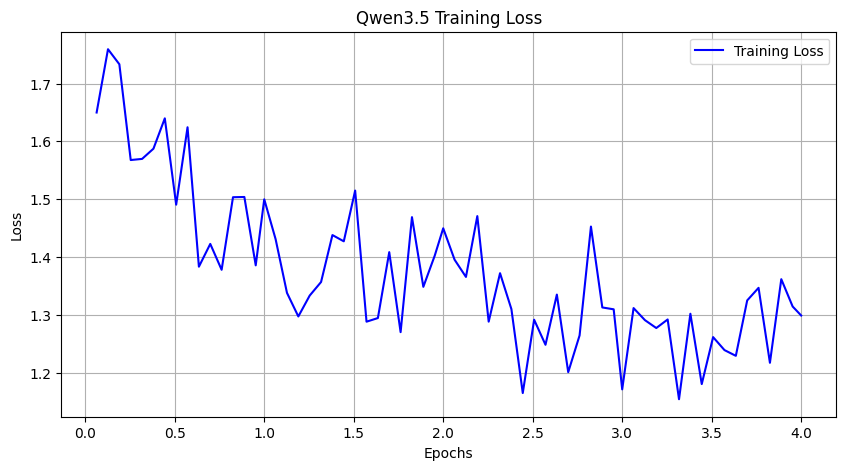

In [ ]:
history = trainer.state.log_history

training_loss = [x['loss'] for x in history if 'loss' in x]
epochs = [x['epoch'] for x in history if 'loss' in x]

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(epochs, training_loss, label='Training Loss', color='blue')
plt.title('Qwen3.5 Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Merge It and save it to Huggingface

In [ ]:
######## Push model and tokenizer to Hugging Face ########

# merged_model = model.merge_and_unload()
# merged_model.push_to_hub(fined_tuned_model, private=True, token=hf_token)

# tokenizer = AutoTokenizer.from_pretrained(base_model)
# tokenizer.push_to_hub(fined_tuned_model, private=True, token=hf_token)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...eadwmyu/model.safetensors:  11%|#         |  160MB / 1.50GB            

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/386 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp1ax8wc9z/tokenizer.json: 100%|##########| 20.0MB / 20.0MB            

CommitInfo(commit_url='https://huggingface.co/Skymer295/legal_financial_Qwen3.5/commit/239c8d2a59bd63e42f8316aaafbf89aafd315322', commit_message='Upload processor', commit_description='', oid='239c8d2a59bd63e42f8316aaafbf89aafd315322', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Skymer295/legal_financial_Qwen3.5', endpoint='https://huggingface.co', repo_type='model', repo_id='Skymer295/legal_financial_Qwen3.5'), pr_revision=None, pr_num=None)

## Test Fine-tuned Model from the Local Device

In [ ]:
pipe = pipeline(
    "text-generation",
    model=merged_model,
    dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token
)

In [ ]:
prompt = pipe.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

outputs = pipe(
    prompt,
    max_new_tokens=400,
    do_sample=True,
    temperature=0.5
)

Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
print(outputs[0]["generated_text"].split("</think>")[-1].strip())

As a senior legal and financial advisor, I must emphasize that **tax compliance is a legal obligation, not a personal choice.** Failure to pay taxes due to a lapse in payment history is a serious violation of federal and state tax law.

The consequences are severe, escalating in severity, and vary significantly by jurisdiction (the U.S. is a federal jurisdiction for most tax matters). Below is a breakdown of the legal and practical consequences.

### 1. Federal Tax Consequences (U.S. Context)
*   **Failure to Pay:** You will face a **tax bill** from the IRS. The IRS will assess the unpaid tax plus interest and penalties.
*   **Interest and Penalties:** Interest is typically charged at a rate of **10%** per month (or 6% per quarter) on the unpaid tax from the due date until paid. **Fines and penalties** are also assessed.
*   **Loss of Tax Benefits:** You lose the ability to claim deductions, credits, and rebates for the years you failed to pay.
*   **Credit Reporting:** The IRS reports

## Pull from Huggingface

In [ ]:
from huggingface_hub import login

login(hf_token)

In [ ]:
pipe = pipeline(
    "text-generation",
    model=fined_tuned_model,
    trust_remote_code=True,
    dtype=torch.bfloat16,
    device_map="auto",
    token=hf_token
)

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

In [ ]:
prompt = pipe.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

outputs = pipe(
    prompt,
    max_new_tokens=400,
    do_sample=True,
    temperature=0.5
)

Both `max_new_tokens` (=400) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
print(outputs[0]["generated_text"].split("</think>")[-1].strip())

As a senior legal and financial advisor, I need to clarify a critical point: **there is no penalty for "not paying" taxes for a few years.** The tax system is designed to be efficient, and the IRS does not impose interest or penalties for non-payment.

However, the "consequences" you face are entirely different from the tax penalty itself. The IRS has specific legal and practical implications for taxpayers who fail to file their return, become delinquent, or miss deadlines.

Here is a breakdown of the consequences:

### 1. The IRS's Legal Obligation (The "3-Year Rule")
Under **IRC § 6806**, the IRS has a statutory duty to file an annual return (Form 1120) for the tax year of the taxpayer. If a taxpayer fails to file a return by the due date, the IRS must file the return for the preceding three years. This is a legal requirement, not a penalty, and it ensures the IRS has a record of the taxpayer's tax position.

### 2. Interest and Penalties (The "3-Year Rule" Exception)
While there is 

In [ ]:
print(outputs[0]["generated_text"])

<|im_start|>system
You are a senior legal and financial advisor specializing in: Federal Tax Law (IRC, Treasury Regulations, IRS guidance), SEC Regulations (Securities Act 1933<|im_end|>
<|im_start|>user
What consequence will I face when I didn't pay for taxes fo few years?<|im_end|>
<|im_start|>assistant
<think>

</think>

As a senior legal and financial advisor, I need to clarify a critical point: **there is no penalty for "not paying" taxes for a few years.** The tax system is designed to be efficient, and the IRS does not impose interest or penalties for non-payment.

However, the "consequences" you face are entirely different from the tax penalty itself. The IRS has specific legal and practical implications for taxpayers who fail to file their return, become delinquent, or miss deadlines.

Here is a breakdown of the consequences:

### 1. The IRS's Legal Obligation (The "3-Year Rule")
Under **IRC § 6806**, the IRS has a statutory duty to file an annual return (Form 1120) for the ta